In [31]:
pm25_o3 = pm25_small.merge(o3_small, on=["date", "city"], how="inner")
pm25_no2 = pm25_small.merge(no2_small, on=["date", "city"], how="inner")
pm25_so2 = pm25_small.merge(so2_small, on=["date", "city"], how="inner")

pm25_o3 = pm25_o3.rename(columns={"PM25_daily": "pm25", "O3_daily": "o3"})
pm25_no2 = pm25_no2.rename(columns={"PM25_daily": "pm25"})
pm25_so2 = pm25_so2.rename(columns={"PM25_daily": "pm25"})

print("PM2.5 + O3 shape :", pm25_o3.shape)
print("PM2.5 + NO2 shape:", pm25_no2.shape)
print("PM2.5 + SO2 shape:", pm25_so2.shape)

PM2.5 + O3 shape : (230625, 4)
PM2.5 + NO2 shape: (204261, 4)
PM2.5 + SO2 shape: (134092, 4)


In [33]:
print("Common PM2.5–O3 cities :", pm25_o3["city"].nunique())
print("Common PM2.5–NO2 cities:", pm25_no2["city"].nunique())
print("Common PM2.5–SO2 cities:", pm25_so2["city"].nunique())

Common PM2.5–O3 cities : 169
Common PM2.5–NO2 cities: 145
Common PM2.5–SO2 cities: 98


In [35]:
pollutant_comparison = pd.DataFrame({
    "Pair": ["PM2.5 vs O3", "PM2.5 vs NO2", "PM2.5 vs SO2"],
    "Correlation": [
        pm25_o3["pm25"].corr(pm25_o3["o3"]),
        pm25_no2["pm25"].corr(pm25_no2["no2"]),
        pm25_so2["pm25"].corr(pm25_so2["so2"]),
    ],
    "Rows Used": [
        len(pm25_o3),
        len(pm25_no2),
        len(pm25_so2),
    ],
    "Cities Covered": [
        pm25_o3["city"].nunique(),
        pm25_no2["city"].nunique(),
        pm25_so2["city"].nunique(),
    ]
})

pollutant_comparison

,Pair,Correlation,Rows Used,Cities Covered
0,PM2.5 vs O3,-0.021340,230625,169
1,PM2.5 vs NO2,0.138359,204261,145
2,PM2.5 vs SO2,0.030200,134092,98


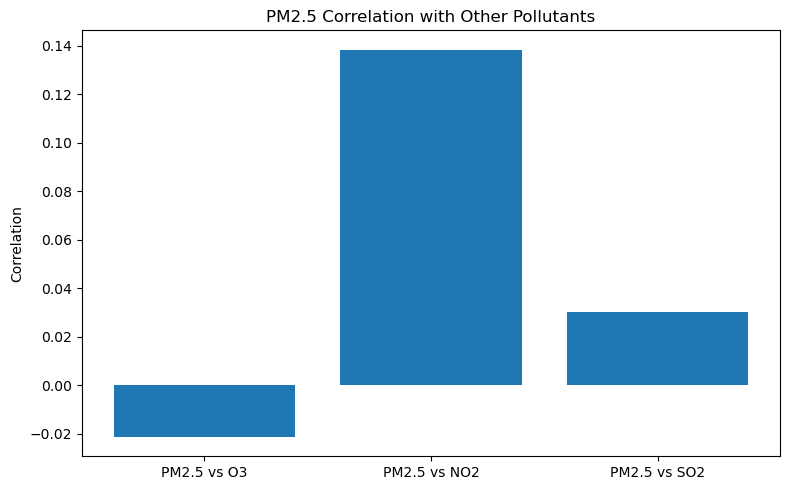

In [37]:
plt.figure(figsize=(8,5))
plt.bar(pollutant_comparison["Pair"], pollutant_comparison["Correlation"])
plt.title("PM2.5 Correlation with Other Pollutants")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

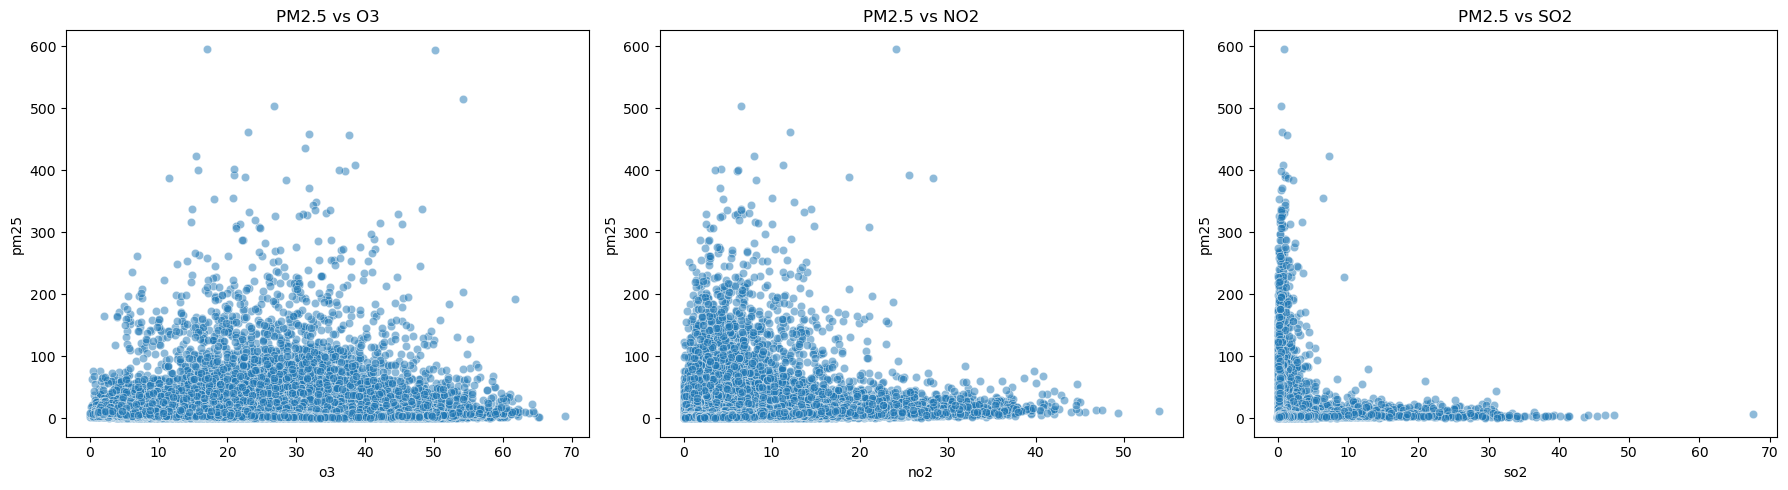

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.scatterplot(data=pm25_o3, x="o3", y="pm25", ax=axes[0], alpha=0.5)
axes[0].set_title("PM2.5 vs O3")

sns.scatterplot(data=pm25_no2, x="no2", y="pm25", ax=axes[1], alpha=0.5)
axes[1].set_title("PM2.5 vs NO2")

sns.scatterplot(data=pm25_so2, x="so2", y="pm25", ax=axes[2], alpha=0.5)
axes[2].set_title("PM2.5 vs SO2")

plt.tight_layout()
plt.show()

In [41]:
city_corr_rows = []

for city, g in pm25_o3.groupby("city"):
    if len(g) > 10:
        city_corr_rows.append({
            "city": city,
            "pair": "PM2.5 vs O3",
            "correlation": g["pm25"].corr(g["o3"])
        })

for city, g in pm25_no2.groupby("city"):
    if len(g) > 10:
        city_corr_rows.append({
            "city": city,
            "pair": "PM2.5 vs NO2",
            "correlation": g["pm25"].corr(g["no2"])
        })

for city, g in pm25_so2.groupby("city"):
    if len(g) > 10:
        city_corr_rows.append({
            "city": city,
            "pair": "PM2.5 vs SO2",
            "correlation": g["pm25"].corr(g["so2"])
        })

city_corr_df = pd.DataFrame(city_corr_rows)
city_corr_df.head()

C:\Users\hetac\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\hetac\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,city,pair,correlation
0,AGASSIZ,PM2.5 vs O3,-0.032632
1,AIRDRIE,PM2.5 vs O3,0.112209
2,ANZAC,PM2.5 vs O3,0.004560
3,ARDROSSAN,PM2.5 vs O3,-0.040540
4,AUCLAIR,PM2.5 vs O3,-0.060051


In [43]:
city_corr_df.sort_values("correlation", ascending=False).head(15)

,city,pair,correlation
309,WHITEHORSE,PM2.5 vs NO2,0.789228
233,LAVAL,PM2.5 vs NO2,0.676140
278,SAINT JOHN,PM2.5 vs NO2,0.632248
286,SMITHERS,PM2.5 vs NO2,0.619836
211,FREDERICTON,PM2.5 vs NO2,0.591737
273,QUEBEC,PM2.5 vs NO2,0.549514
235,LEVIS,PM2.5 vs NO2,0.545690
177,BRAMPTON,PM2.5 vs NO2,0.530198
298,TERRACE,PM2.5 vs NO2,0.527111
248,METRO VAN - WEST VANCOUVER,PM2.5 vs NO2,0.524822


In [47]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

for d in [pm25_o3, pm25_no2, pm25_so2]:
    d["Month"] = d["date"].dt.month
    d["Season"] = d["Month"].apply(get_season)

In [49]:
seasonal_no2 = pm25_no2.groupby("Season")[["pm25", "no2"]].mean()
seasonal_so2 = pm25_so2.groupby("Season")[["pm25", "so2"]].mean()
seasonal_o3  = pm25_o3.groupby("Season")[["pm25", "o3"]].mean()

print("PM2.5 vs NO2 seasonal averages")
display(seasonal_no2)

print("PM2.5 vs SO2 seasonal averages")
display(seasonal_so2)

print("PM2.5 vs O3 seasonal averages")
display(seasonal_o3)

PM2.5 vs NO2 seasonal averages


,pm25,no2
Season,,
Fall,7.236747,5.256204
Spring,6.042620,4.662281
Summer,9.138116,3.478149
Winter,6.124473,7.529840


PM2.5 vs SO2 seasonal averages


,pm25,so2
Season,,
Fall,7.483221,0.519003
Spring,6.327689,0.636523
Summer,9.734568,0.578076
Winter,5.895619,0.609801


PM2.5 vs O3 seasonal averages


,pm25,o3
Season,,
Fall,6.932643,20.938855
Spring,5.877477,32.789223
Summer,9.085418,25.333802
Winter,6.165600,25.065237


In [51]:
pollutant_comparison.to_csv("../results/pollutant_comparison_summary.csv", index=False)
city_corr_df.to_csv("../results/pollutant_citywise_correlations.csv", index=False)

print("Saved successfully")

Saved successfully


## Pollutant Comparison
Pairwise comparison was used because pollutant datasets did not have identical city and date coverage.

The results show how PM2.5 relates to O₃, NO₂, and SO₂ using overlapping observations across cities.

Key findings:
PM2.5 shows the strongest positive association with NO₂ (r ≈ 0.14), indicating shared emission sources such as traffic and combustion

PM2.5 has a weak positive relationship with SO₂ (r ≈ 0.03), suggesting a smaller industrial contribution

PM2.5 shows a very weak negative relationship with O₃ (r ≈ −0.02), reflecting different atmospheric formation behavior

City-level variation confirms pollutant relationships are location-specific

These results support the inclusion of exogenous pollutants in SARIMAX models for improved forecasting performance